## 1. Import dan Pemahaman Dataset

### 1.1 Import Library

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

### 1.2 Import Dataset

In [10]:
df = pd.read_excel("films_raw.xlsx")
df.head()

,Title,Year,Director_raw,Starring_raw,Production_Company,Box_Office_Gross_raw
0,Toy Story 3,2010,NaN,NaN,Disney,NaN
1,Alice in Wonderland,2010,NaN,NaN,"$334,191,110",NaN
2,Iron Man 2,2010,NaN,NaN,Paramount,NaN
3,The Twilight Saga: Eclipse,2010,NaN,NaN,Summit,NaN
4,Harry Potter and the Deathly Hallows – Part 1,2010,NaN,NaN,Warner Bros.,NaN


**Struktur dataset:** dataset berisi 6 kolom hasil scraping dari Wikipedia
(`List of American films of [Year]`, 2010–2025):
- `Title` — judul film
- `Year` — tahun rilis
- `Director_raw` — nama sutradara (mentah, belum dibersihkan)
- `Starring_raw` — daftar pemeran (mentah)
- `Production_Company` — studio produksi
- `Box_Office_Gross_raw` — pendapatan box office (masih teks, contoh: "$334,191,110")

### 1.3 Info Umum Dataset

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3604 entries, 0 to 3603
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Title                 3604 non-null   str    
 1   Year                  3604 non-null   int64  
 2   Director_raw          0 non-null      float64
 3   Starring_raw          0 non-null      float64
 4   Production_Company    2969 non-null   str    
 5   Box_Office_Gross_raw  0 non-null      float64
dtypes: float64(3), int64(1), str(2)
memory usage: 169.1 KB


In [12]:
print("Jumlah baris dan kolom :", df.shape)
print("\nTipe data tiap kolom:\n", df.dtypes)

Jumlah baris dan kolom : (3604, 6)

Tipe data tiap kolom:
 Title                       str
Year                      int64
Director_raw            float64
Starring_raw            float64
Production_Company          str
Box_Office_Gross_raw    float64
dtype: object


### 1.4 Identifikasi Tipe Atribut

Berdasarkan `.info()` dan `.dtypes`, setiap atribut dapat diklasifikasikan sebagai berikut:

| Kolom | Tipe Data (pandas) | Jenis Atribut | Keterangan |
|---|---|---|---|
| `Title` | object (str) | **Nominal** | Nama/label unik, tidak punya urutan |
| `Year` | int64 | **Numerik Diskrit** | Angka tahun, bilangan bulat, bisa juga dipakai sebagai kategori waktu |
| `Director_raw` | object (str) | **Nominal** | Nama orang, tidak punya urutan |
| `Starring_raw` | object (str) | **Nominal** | Daftar nama pemeran, tidak punya urutan |
| `Production_Company` | object (str) | **Nominal** | Nama studio, tidak punya urutan |
| `Box_Office_Gross_raw` | object (str, akan dikonversi) | **Numerik Kontinu** | Nilai uang (USD), bisa berupa pecahan tak terhingga dalam rentangnya |

Catatan: tidak ada atribut **ordinal** dalam dataset ini (tidak ada kategori yang punya tingkatan/urutan bermakna seperti "rendah-sedang-tinggi").

## 2. Data Cleaning (Persiapan Sebelum Analisis)

Sebelum masuk ke analisis statistik, beberapa kolom perlu dibersihkan terlebih dahulu:
- String kosong/spasi diseragamkan menjadi `NaN`.
- `Box_Office_Gross_raw` (teks seperti `"$334,191,110"`) dikonversi menjadi kolom numerik `Box_Office_Clean`.
- Missing value pada kolom kategorikal diisi dengan label `"Unknown"` / `"Other/Independent"` agar tidak mengganggu perhitungan frekuensi.

In [13]:
# Menyeragamkan string kosong/spasi menjadi NaN murni
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
print("Jumlah NaN aktual per kolom:\n", df.isnull().sum())

Jumlah NaN aktual per kolom:
 Title                      0
Year                       0
Director_raw            3604
Starring_raw            3604
Production_Company       635
Box_Office_Gross_raw    3604
dtype: int64


In [14]:
# 1. Pastikan kolom tujuan bisa menerima teks
df['Box_Office_Gross_raw'] = df['Box_Office_Gross_raw'].astype(object)

# 2. Filter dengan aman (ubah ke string dulu agar tidak error jika ada angka)
mask = df['Production_Company'].astype(str).str.contains(r'\$')

print(f"Jumlah data salah: {mask.sum()}")

# 3. Pindahkan datanya
df.loc[mask, 'Box_Office_Gross_raw'] = df.loc[mask, 'Production_Company']

# 4. Kosongkan nilai awalnya dengan np.nan (lebih aman untuk semua versi Pandas)
df.loc[mask, 'Production_Company'] = np.nan

# Cek hasilnya
display(df.loc[mask, ['Production_Company', 'Box_Office_Gross_raw']].head())


Jumlah data salah: 27


,Production_Company,Box_Office_Gross_raw
1,NaN,"$334,191,110"
5,NaN,"$292,576,195"
8,NaN,"$217,581,231"
560,NaN,"$400,738,009"
563,NaN,"$274,092,705"


In [15]:
# Mengubah teks box office mentah menjadi angka float.
def clean_box_office(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).replace('$', '').replace(',', '').strip()
    match = re.search(r'[\d\.]+', val_str)
    if match:
        try:
            return float(match.group())
        except ValueError:
            return np.nan
    return np.nan

df['Box_Office_Clean'] = df['Box_Office_Gross_raw'].apply(clean_box_office)
df[['Box_Office_Gross_raw', 'Box_Office_Clean']].head()

,Box_Office_Gross_raw,Box_Office_Clean
0,NaN,NaN
1,"$334,191,110",334191110.0
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


In [16]:
# Mengisi missing value kolom kategorikal
df['Director_raw'] = df['Director_raw'].fillna('Unknown')
df['Starring_raw'] = df['Starring_raw'].fillna('Unknown')
df['Production_Company'] = df['Production_Company'].fillna('Other/Independent')

print("Jumlah missing value setelah cleaning:\n", df.isnull().sum())

Jumlah missing value setelah cleaning:
 Title                      0
Year                       0
Director_raw               0
Starring_raw               0
Production_Company         0
Box_Office_Gross_raw    3577
Box_Office_Clean        3577
dtype: int64


In [17]:
# Pisahkan data yang punya target (box office terisi) vs yang belum (2024-2026)
df_train = df[df['Box_Office_Clean'].notna()].copy()
df_predict = df[df['Box_Office_Clean'].isna()].copy()

print(f"Data dengan Box Office (siap untuk training) : {len(df_train)} baris")
print(f"Data tanpa Box Office (untuk diprediksi nanti): {len(df_predict)} baris")

Data dengan Box Office (siap untuk training) : 27 baris
Data tanpa Box Office (untuk diprediksi nanti): 3577 baris


## 3. Analisis Statistik dan Kualitas Data

### 3.1 Statistik Deskriptif — Atribut Numerik

In [18]:
numeric_cols = ['Year', 'Box_Office_Clean']

desc_stats = df[numeric_cols].describe().T
desc_stats['median'] = df[numeric_cols].median()
desc_stats['mode'] = df[numeric_cols].mode().iloc[0]
desc_stats[['mean', 'median', 'mode', 'std', 'min', 'max']]

,mean,median,mode,std,min,max
Year,2.018689e+03,2020.0,2024.0,4.837713e+00,2010.0,2025.0
Box_Office_Clean,3.811597e+08,369695210.0,46801036.0,1.515330e+08,46801036.0,678815482.0


### 3.2 Distribusi/Frekuensi Atribut Kategorikal

In [19]:
categorical_cols = ['Production_Company', 'Director_raw']

for col in categorical_cols:
    print(f"--- Top 10 {col} ---")
    print(df[col].value_counts().head(10))
    print()

--- Top 10 Production_Company ---
Production_Company
Other/Independent    662
Disney                40
Netflix               30
Warner Bros.          25
Universal             25
Lionsgate             16
Paramount             13
HBO Films             13
20th Century Fox      12
Sony                  12
Name: count, dtype: int64

--- Top 10 Director_raw ---
Director_raw
Unknown    3604
Name: count, dtype: int64



### 3.3 Identifikasi Missing Value per Atribut

In [20]:
missing_summary = pd.DataFrame({
    'Jumlah_Missing': df.isnull().sum(),
    'Persentase_Missing (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_summary

,Jumlah_Missing,Persentase_Missing (%)
Title,0,0.00
Year,0,0.00
Director_raw,0,0.00
Starring_raw,0,0.00
Production_Company,0,0.00
Box_Office_Gross_raw,3577,99.25
Box_Office_Clean,3577,99.25


**Interpretasi:** `Box_Office_Clean` memiliki missing value paling besar — ini **sesuai ekspektasi**,
karena film-film rilis 2024-2026 memang belum memiliki data box office final di Wikipedia (data ini
justru menjadi target yang ingin diprediksi menggunakan machine learning).

### 3.4 Deteksi Outlier pada Atribut Numerik (Box_Office_Clean)

In [21]:
Q1 = df['Box_Office_Clean'].quantile(0.25)
Q3 = df['Box_Office_Clean'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Box_Office_Clean'] < lower_bound) | (df['Box_Office_Clean'] > upper_bound)]

print(f"Q1 = {Q1:,.0f}, Q3 = {Q3:,.0f}, IQR = {IQR:,.0f}")
print(f"Batas bawah = {lower_bound:,.0f}, Batas atas = {upper_bound:,.0f}")
print(f"Jumlah outlier terdeteksi: {len(outliers)} dari {df['Box_Office_Clean'].notna().sum()} data valid")
outliers[['Title', 'Year', 'Box_Office_Clean']].sort_values('Box_Office_Clean', ascending=False).head(10)

Q1 = 287,360,276, Q3 = 481,834,570, IQR = 194,474,293
Batas bawah = -4,351,163, Batas atas = 773,546,009
Jumlah outlier terdeteksi: 0 dari 27 data valid


,Title,Year,Box_Office_Clean


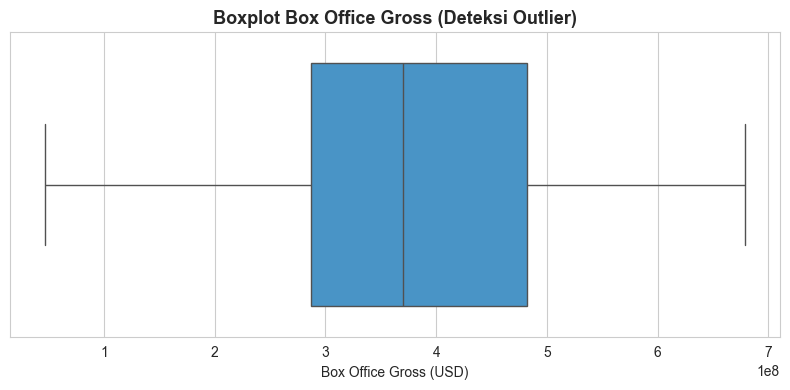

In [22]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Box_Office_Clean'].dropna(), color='#3498db')
plt.title('Boxplot Box Office Gross (Deteksi Outlier)', fontsize=13, fontweight='bold')
plt.xlabel('Box Office Gross (USD)')
plt.tight_layout()
plt.show()


## 4. Visualisasi Data

### 4.1 Univariat — Histogram Atribut Numerik (Box_Office_Clean)

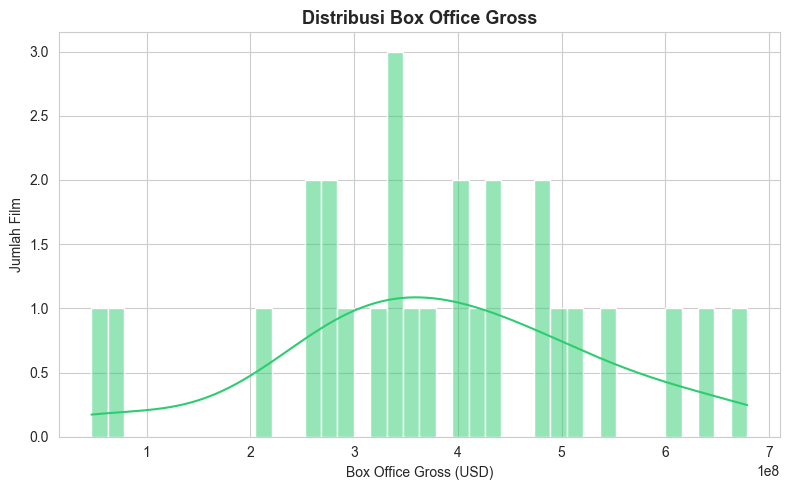

In [23]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Box_Office_Clean'].dropna(), bins=40, kde=True, color='#2ecc71')
plt.title('Distribusi Box Office Gross', fontsize=13, fontweight='bold')
plt.xlabel('Box Office Gross (USD)')
plt.ylabel('Jumlah Film')
plt.tight_layout()
plt.show()

Insight: Histogram terlihat bahwa beberapa studio tidak memberikan data pendapatannya dan pendapatan didominasi oleh studio besar

### 4.2 Univariat — Bar Chart Atribut Kategorikal (Production_Company)

C:\Users\M S I\AppData\Local\Temp\ipykernel_25876\2437322430.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_studios.values, y=top_studios.index, palette='viridis')


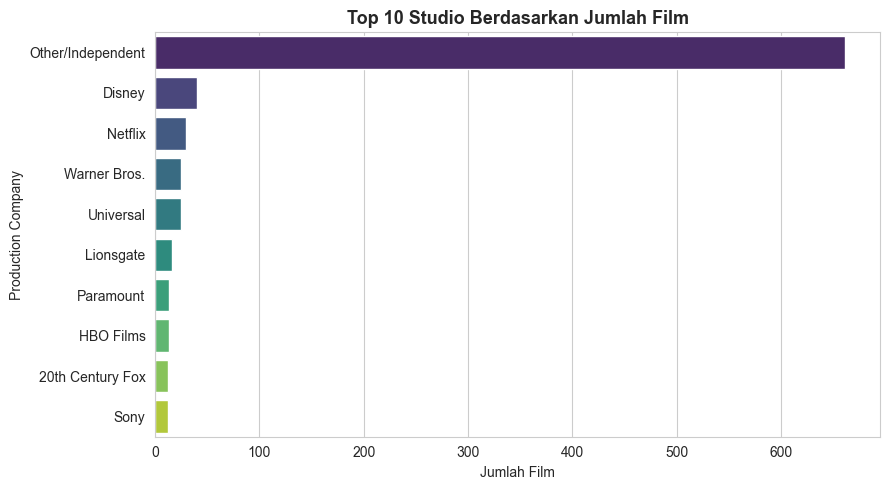

In [24]:
top_studios = df['Production_Company'].value_counts().head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_studios.values, y=top_studios.index, palette='viridis')
plt.title('Top 10 Studio Berdasarkan Jumlah Film', fontsize=13, fontweight='bold')
plt.xlabel('Jumlah Film')
plt.ylabel('Production Company')
plt.tight_layout()
plt.show()

**Insight:** studio-studio besar (mis. Warner Bros., Universal, Disney) mendominasi jumlah rilis film
dibanding studio independen, mencerminkan konsentrasi produksi film Hollywood pada segelintir major studio.

### 4.3 Univariat — Status Ketersediaan Data Box Office

Jumlah sampel ketersediaan data Box Office:
 Status_Box_Office
Kosong/NA    3577
Tersedia       27
Name: count, dtype: int64


C:\Users\M S I\AppData\Local\Temp\ipykernel_25876\2040020521.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Status_Box_Office', data=df, palette=['#2ecc71', '#e74c3c'],


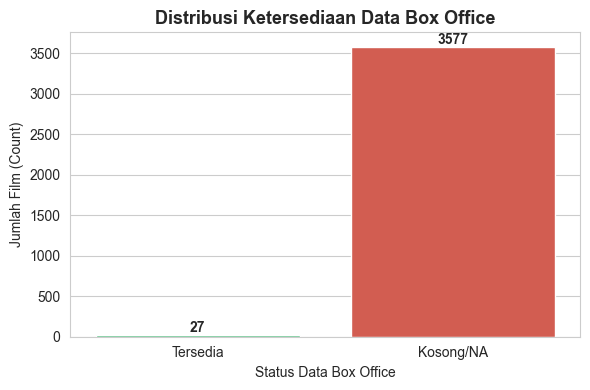

In [25]:
df['Status_Box_Office'] = df['Box_Office_Clean'].apply(
    lambda x: 'Tersedia' if pd.notna(x) else 'Kosong/NA'
)
status_counts = df['Status_Box_Office'].value_counts()
print("Jumlah sampel ketersediaan data Box Office:\n", status_counts)

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Status_Box_Office', data=df, palette=['#2ecc71', '#e74c3c'],
                    order=['Tersedia', 'Kosong/NA'])
plt.title('Distribusi Ketersediaan Data Box Office', fontsize=13, fontweight='bold')
plt.xlabel('Status Data Box Office')
plt.ylabel('Jumlah Film (Count)')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2.0, p.get_height()),
                ha='center', va='center', xytext=(0, 5),
                textcoords='offset points', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** proporsi data yang memiliki nilai box office lengkap jauh lebih besar dibanding yang kosong,
namun bagian yang kosong (`Kosong/NA`) inilah yang menjadi **data uji/prediksi** untuk model ML nantinya
(film-film 2024–2026 yang belum lengkap datanya).

### 4.4 Bivariat — Tren Rata-Rata Box Office per Tahun (Line Plot)

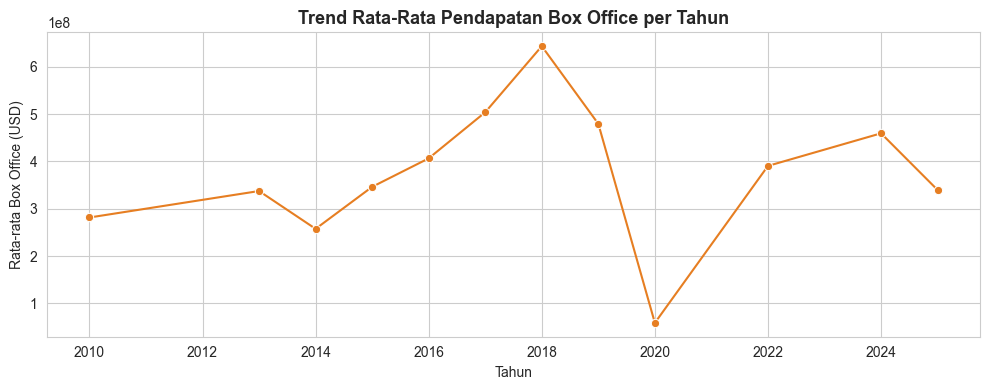

In [26]:
yearly_gross = df.groupby('Year')['Box_Office_Clean'].mean().reset_index()

plt.figure(figsize=(10, 4))
sns.lineplot(x='Year', y='Box_Office_Clean', data=yearly_gross, marker='o', color='#e67e22')
plt.title('Trend Rata-Rata Pendapatan Box Office per Tahun', fontsize=13, fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Rata-rata Box Office (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

**Insight:** terlihat fluktuasi rata-rata box office antar tahun, termasuk kemungkinan penurunan
tajam pada tahun 2020–2021 (kemungkinan besar dampak pandemi COVID-19 terhadap industri bioskop).
Tahun-tahun dengan data tidak lengkap (2024-2026) sebaiknya diinterpretasi hati-hati karena jumlah
sampel valid-nya jauh lebih sedikit.

### 4.5 Bivariat — Top 10 Studio Berdasarkan Total Box Office (Bar Chart)

C:\Users\M S I\AppData\Local\Temp\ipykernel_25876\1275086261.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Box_Office_Clean', y='Production_Company', data=top_gross_studio, palette='Blues_r')


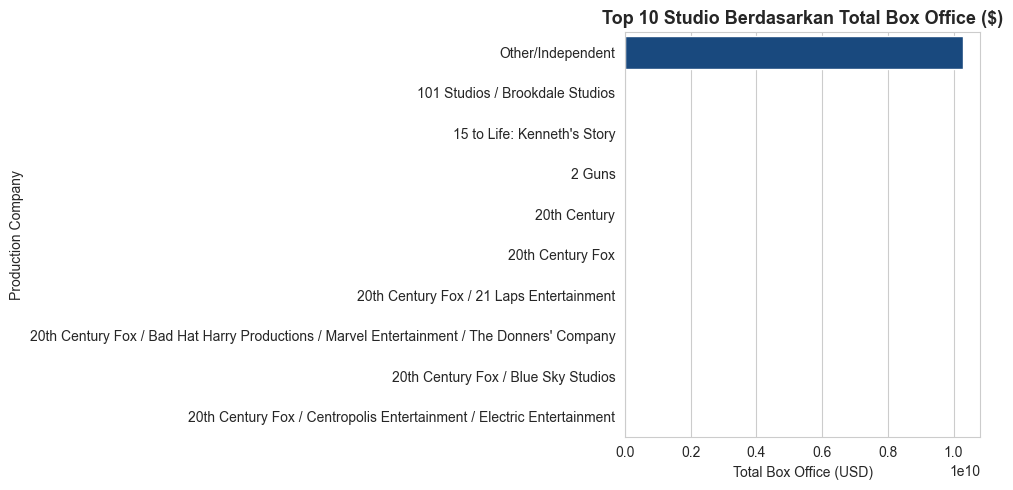

In [27]:
top_gross_studio = (
    df.groupby('Production_Company')['Box_Office_Clean']
    .sum()
    .nlargest(10)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(x='Box_Office_Clean', y='Production_Company', data=top_gross_studio, palette='Blues_r')
plt.title('Top 10 Studio Berdasarkan Total Box Office ($)', fontsize=13, fontweight='bold')
plt.xlabel('Total Box Office (USD)')
plt.ylabel('Production Company')
plt.tight_layout()
plt.show()

Insight: Histogram terlihat bahwa studio menguasai chart karena dari data yang tersedia studio studio lain tidak tersedia


### 4.6 Bivariat — Scatter Plot: Tahun vs Box Office

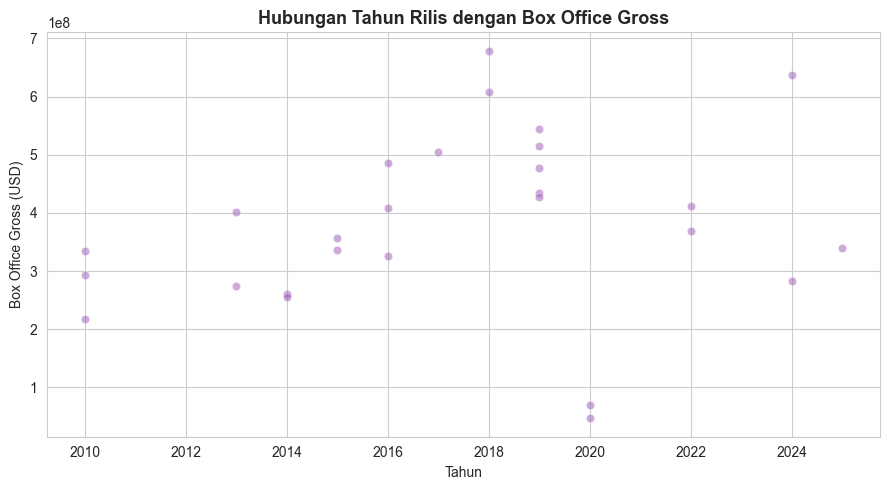

In [28]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x='Year', y='Box_Office_Clean', data=df, alpha=0.5, color='#9b59b6')
plt.title('Hubungan Tahun Rilis dengan Box Office Gross', fontsize=13, fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Box Office Gross (USD)')
plt.tight_layout()
plt.show()

Insight: Histogram terlihat pada tahun 2018 mengalami peningkatan yang tinggi dan terjadi penurunan drastis di tahun 2020. Kemudian data terlihat kembali normal di tahun 2022 tepat setelah selesai pandemi.

### 4.7 Correlation Heatmap

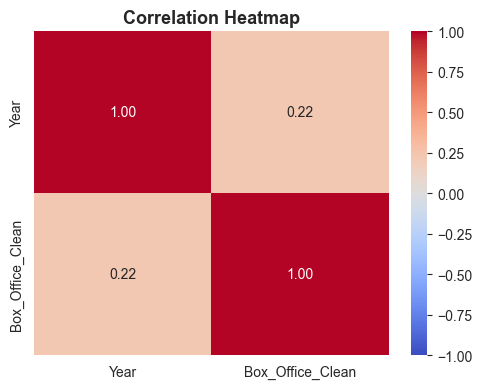

In [29]:
corr = df[['Year', 'Box_Office_Clean']].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** korelasi antara `Year` dan `Box_Office_Clean` sangat lemah (mendekati 0), menegaskan
temuan dari scatter plot bahwa tahun rilis bukan prediktor kuat untuk box office secara langsung.
Fitur kategorikal seperti `Production_Company` atau `Director_raw` kemungkinan berperan lebih besar,
dan perlu dieksplorasi lebih lanjut melalui encoding pada tahap machine learning.